In [12]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

from math import ceil


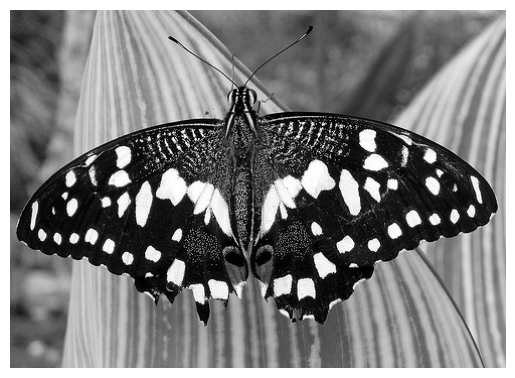

In [13]:
butterfly = cv.imread('images/butterfly.jpg')
butterfly_img = cv.imread('images/butterfly.jpg', cv.IMREAD_GRAYSCALE)
# Display the image
plt.imshow(butterfly_img, cmap='gray')
plt.axis('off')  # Hide axes
plt.show()

Normalize the image


In [14]:
normalized_img = butterfly_img.astype(np.float32) / 255.0

Creating laplacian of gaussian
The **Laplacian of Gaussian** is defined as:

$$\text{LoG}(x, y) = -\frac{1}{\pi\sigma^4}\left[1 - \frac{x^2 + y^2}{2\sigma^2}\right]e^{-\frac{x^2 + y^2}{2\sigma^2}}$$


Kernel size: 73x73
Sum of kernel elements: 6.505213034913027e-19


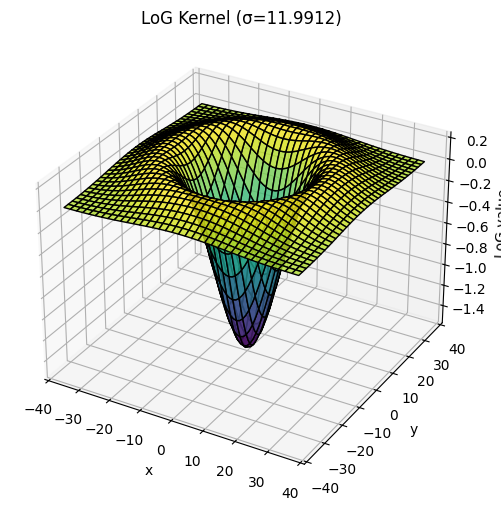

array([[7.64421585e-08, 8.00571881e-08, 8.43797353e-08, ...,
        8.43797353e-08, 8.00571881e-08, 7.64421585e-08],
       [8.00571881e-08, 8.45186226e-08, 8.98459657e-08, ...,
        8.98459657e-08, 8.45186226e-08, 8.00571881e-08],
       [8.43797353e-08, 8.98459657e-08, 9.63638160e-08, ...,
        9.63638160e-08, 8.98459657e-08, 8.43797353e-08],
       ...,
       [8.43797353e-08, 8.98459657e-08, 9.63638160e-08, ...,
        9.63638160e-08, 8.98459657e-08, 8.43797353e-08],
       [8.00571881e-08, 8.45186226e-08, 8.98459657e-08, ...,
        8.98459657e-08, 8.45186226e-08, 8.00571881e-08],
       [7.64421585e-08, 8.00571881e-08, 8.43797353e-08, ...,
        8.43797353e-08, 8.00571881e-08, 7.64421585e-08]], shape=(73, 73))

In [15]:
def LoG_kernal(sigma, debug=False):
    half_width = int(ceil(3*sigma))
    width = 2*half_width + 1

    y, x = np.mgrid[-half_width:half_width+1, -half_width:half_width+1]

    r_2 = x**2 + y**2
    # Laplacian of Gaussian formula
    LoG = -1/(np.pi * sigma**4) * (1 - r_2/(2*sigma**2)) * np.exp(-r_2/(2*sigma**2))

    # making the sum of kernel elements zero
    LoG -= LoG.mean()

    if debug:
        print(f"Kernel size: {width}x{width}")
        print(f"Sum of kernel elements: {LoG.sum()}")
        # 3D plot
        fig = plt.figure(figsize=(8,6))
        ax = fig.add_subplot(111, projection='3d')
        ax.plot_surface(x, y, LoG, cmap='viridis', edgecolor='k', alpha=0.8)
        ax.set_title(f"LoG Kernel (σ={sigma})")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_zlabel("LoG value")
        plt.show()

    return LoG


LoG_kernal(11.9912, debug=True)


##### Why LoG needs to be zero-mean?
The LoG kernel is designed to highlight regions of intensity change (blobs) rather than the overall brightness.

Without zero-mean:

The kernel might have a small positive or negative bias.

Convolution could produce a nonzero response even on uniform areas.

With zero-mean:

A flat region (constant intensity) produces zero response.

Only areas where intensity changes (like blobs, spots, or edges) give nonzero response.

Scale space Parameters


In [16]:
initial_sigma = 2.0
k = 1.2
n_levels = 12
sigmas = [initial_sigma * (k**i) for i in range(n_levels)]
print("Scale levels (σ):", sigmas)

Scale levels (σ): [2.0, 2.4, 2.88, 3.4559999999999995, 4.1472, 4.976639999999999, 5.971967999999999, 7.166361599999998, 8.599633919999997, 10.319560703999997, 12.383472844799995, 14.860167413759994]


Building the scale space

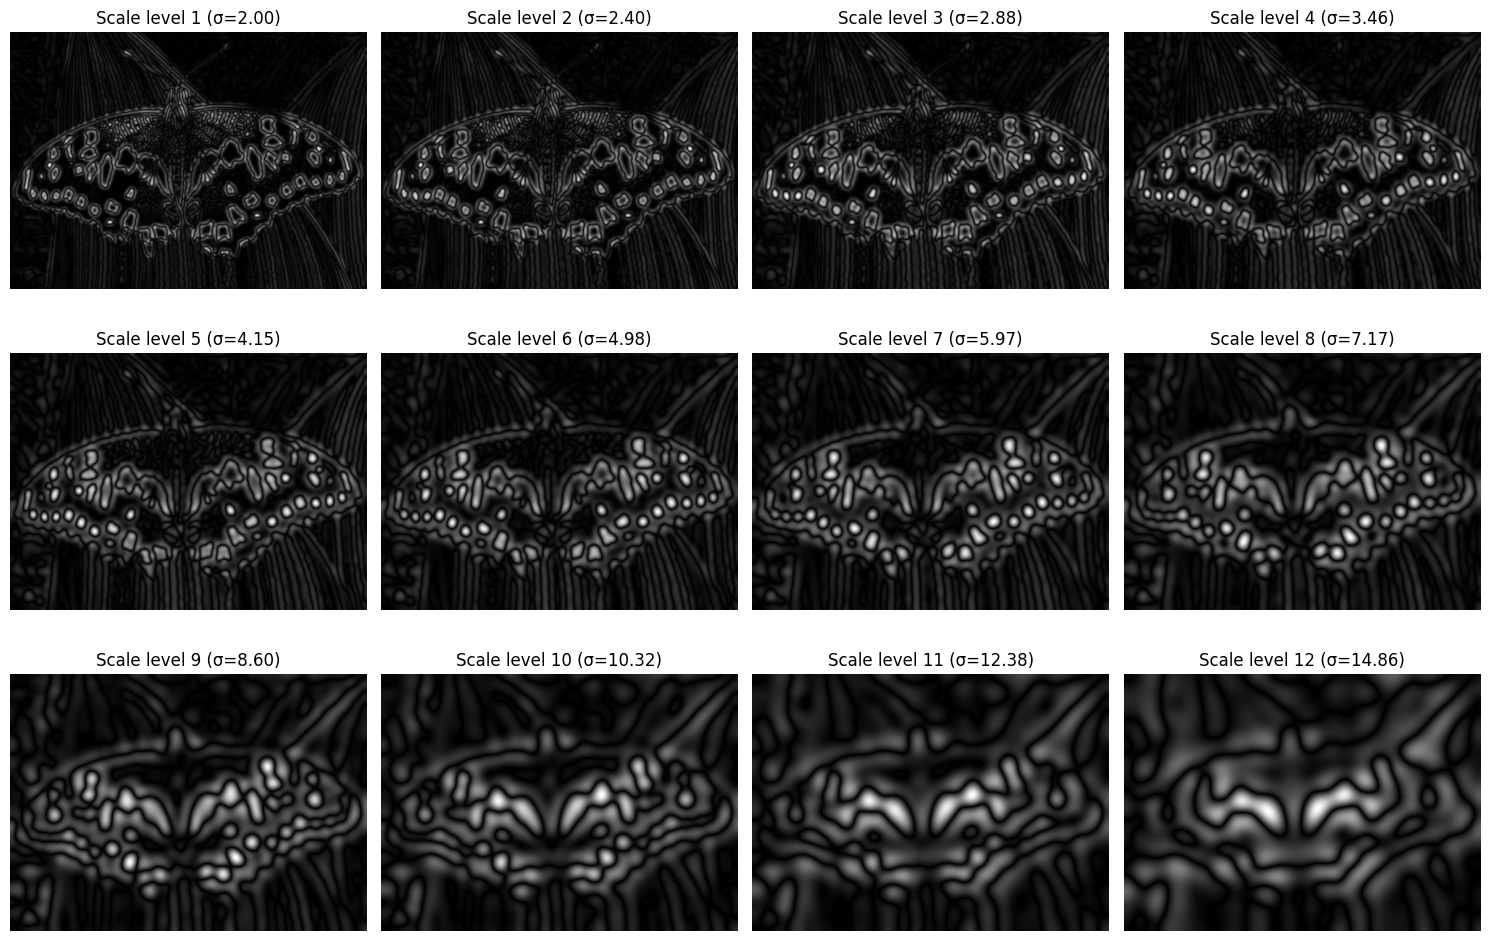

In [17]:
height, width = normalized_img.shape
scale_space = np.zeros((height, width, n_levels), dtype=np.float32)

for i, sigma in enumerate(sigmas):
    LoG = LoG_kernal(sigma)
    filtered_img = cv.filter2D(normalized_img, -1, LoG)
    # Scale-normalized LoG response of the squared laplacian response
    scale_space[:, :, i] = (sigma**2) * np.abs(filtered_img)

# Visualize some scale levels
n_display = 12
plt.figure(figsize=(15, 10))
for i in range(n_display):
    plt.subplot(3, 4, i+1)
    plt.imshow(scale_space[:, :, i*(n_levels//n_display)], cmap='gray')
    plt.title(f'Scale level {i*(n_levels//n_display)+1} (σ={sigmas[i*(n_levels//n_display)]:.2f})')
    plt.axis('off')
plt.tight_layout()
plt.show()

Finding the maxima in scale space

#### 2D Non-maximum suppression

In [18]:
from scipy import ndimage

def nonmax2d(response, neighborhood=3):
    """Return boolean mask of pixels that are local maxima in a neighborhood."""
    if neighborhood % 2 == 0:
        neighborhood += 1
    footprint = np.ones((neighborhood, neighborhood), dtype=bool)
    local_max = ndimage.maximum_filter(response, footprint=footprint, mode='reflect')
    mask = (response == local_max)
    return mask

nms2d_masks = np.zeros_like(scale_space, dtype=bool)
for i in range(n_levels):
    nms2d_masks[:, :, i] = nonmax2d(scale_space[:, :, i], neighborhood=3)


#### 3D Non-maximum suppression (across scales)

In [19]:
candidates = []
for i in range(n_levels):
    resp = scale_space[:, :, i]
    mask2d = nms2d_masks[:, :, i]
    if i == 0:
        is_scale_max = (resp >= scale_space[:, :, i+1])
    elif i == n_levels - 1:
        is_scale_max = (resp >= scale_space[:, :, i-1])
    else:
        is_scale_max = (resp >= scale_space[:, :, i-1]) & (resp >= scale_space[:, :, i+1])

    final_mask = mask2d & is_scale_max
    ys, xs = np.nonzero(final_mask)
    for y, x in zip(ys, xs):
        candidates.append((y, x, i, float(resp[y, x])))


Thresholding & ranking

In [20]:
threshold = 1e-5   # tune per dataset; lower => more blobs
max_blobs = 1000

# filter by threshold and convert scale index to sigma
blobs = []
for (y, x, scale_idx, resp_val) in candidates:
    if resp_val >= threshold:
        sigma = sigmas[scale_idx]
        blobs.append((y, x, sigma, resp_val))

# sort and keep top
blobs.sort(key=lambda b: b[3], reverse=True)
blobs = blobs[:max_blobs]


In [21]:
from math import sqrt

def sigma_to_radius(sigma):
    return int(round(sqrt(2) * sigma))


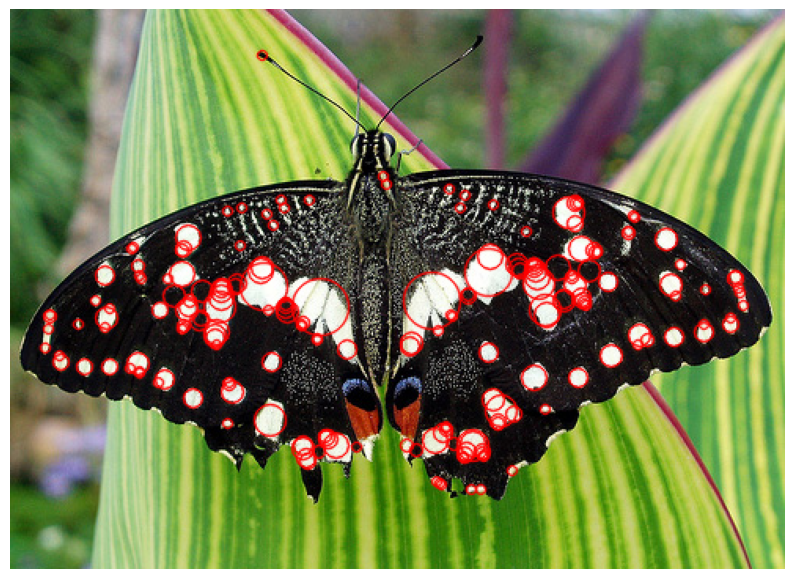

In [22]:
def draw_blobs(img_bgr, blobs, radius_factor=sqrt(2), color=(0,0,255)):
    out = img_bgr.copy()
    for (y, x, sigma, resp) in blobs:
        r = int(round(radius_factor * sigma))
        cv.circle(out, (int(x), int(y)), r, color, 1, lineType=cv.LINE_AA)
    return out

# Example
out = draw_blobs(butterfly, blobs[:200])  # draw top 200

# PLOT USING MATPLOTLIB
plt.figure(figsize=(10, 10))
plt.imshow(cv.cvtColor(out, cv.COLOR_BGR2RGB))
plt.axis('off')  # Hide axes
plt.show()

